# One dimensional dummy problem

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho-\rho v \partial_x v+\mu\partial_x^2 v -S\\
\partial_t\rho&=-(\partial_x \rho)v-\rho (\partial_x v) + \mu_\epsilon\partial_x^2\rho-\dot m \\
\partial_t \rho_s &= \dot m \\
\dot m &= A \ln \left( \frac{p_g}{p_{\text{eq},a}}\right)\left(\rho_{\text{sat}} - \rho_s\right)
\end{aligned}
\end{equation}

Where

\begin{equation}
S = \frac{\mu}{K}v
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
p_{\text{tot}} = RT\rho+\frac{1}{2}\rho v^2 &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

In [2]:
using OrdinaryDiffEq, MethodOfLines, DomainSets, ModelingToolkit;

## Definitions

In [3]:
# Parameters, variables, and derivatives
@parameters x, t
@variables ρ(..) v(..) ρ_s(..)

# definitions of derivatives
Dt = Differential(t)
Dx = Differential(x)
Dxx = Differential(x)^2

# constants
R = 1.0
T = 1.0
μ = 1.0
μρ = 0.001
K = 1.0
A = 1.0
p_eqa = 1.0
ρ_sat = 1.0

# PDE
eq = [
    Dt(v(x, t))     ~ (-R*T*Dx(ρ(x, t))+μ*Dxx(v(x, t))-ρ(x, t)*v(x, t)*Dx(v(x, t))-v(x, t)*μ/K)/ρ(x, t),
    Dt(ρ(x, t))     ~ -Dx(ρ(x, t))*v(x, t)-ρ(x, t)*Dx(v(x, t))+μρ*Dxx(ρ(x, t))-A*log(R*T*ρ(x, t)/p_eqa)*(ρ_sat-ρ_s(x,t)),
    Dt(ρ_s(x, t))   ~ A*log(R*T*ρ(x, t)/p_eqa)*(ρ_sat-ρ_s(x,t))
]

# Boundary conditions
bcs = [

    # initial conditions
    ρ(x, 0)   ~ 1.0,
    v(x, 0)   ~ 0.0,
    ρ_s(x, 0) ~ 0.0,

    # total-pressure inlet BC
    ρ(0, t) ~ (
        2.0 - exp(-10.0*t)
    ) / (
        R*T + 0.5*v(0,t)^2
    ),

    # velocity BCs
    Dx(v(0, t)) ~ 0.0,
    v(1, t) ~ 0.0
]

# Space and time domains
domains = [
    x ∈ Interval(0.0, 1.0),
    t ∈ Interval(0.0, 10.0)
]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(x, 0.0 .. 1.0)
 Symbolics.VarDomainPairing(t, 0.0 .. 10.0)

## PDE

In [4]:
# PDE system
@named pdesys = PDESystem(
    eq, 
    bcs, 
    domains, 
    [x, t], [ρ(x, t), v(x, t), ρ_s(x, t)]
)

PDESystem
Equations: Equation[Differential(t, 1)(v(x, t)) ~ (Differential(x, 2)(v(x, t)) - Differential(x, 1)(ρ(x, t)) - v(x, t) - Differential(x, 1)(v(x, t))*v(x, t)*ρ(x, t)) / ρ(x, t), Differential(t, 1)(ρ(x, t)) ~ 0.001Differential(x, 2)(ρ(x, t)) - Differential(x, 1)(ρ(x, t))*v(x, t) - Differential(x, 1)(v(x, t))*ρ(x, t) - log(ρ(x, t))*(1.0 - ρ_s(x, t)), Differential(t, 1)(ρ_s(x, t)) ~ log(ρ(x, t))*(1.0 - ρ_s(x, t))]
Boundary Conditions: Equation[ρ(x, 0) ~ 1.0, v(x, 0) ~ 0.0, ρ_s(x, 0) ~ 0.0, ρ(0, t) ~ (2.0 - exp(-10.0t)) / (1.0 + 0.5(v(0, t)^2)), Differential(x, 1)(v(0, t)) ~ 0.0, v(1, t) ~ 0.0]
Domain: Symbolics.VarDomainPairing[Symbolics.VarDomainPairing(x, 0.0 .. 1.0), Symbolics.VarDomainPairing(t, 0.0 .. 10.0)]
Dependent Variables: Num[ρ(x, t), v(x, t), ρ_s(x, t)]
Independent Variables: Num[x, t]
Parameters: SciMLBase.NullParameters()
Default Parameter ValuesModelingToolkitBase.AtomicArrayDict{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}, Dict{Symboli

In [5]:
# Method of lines discretization
dx = .02
order = 1

MOL_scheme = UpwindScheme(order)
discretization = MOLFiniteDifference([x => dx], t, advection_scheme = MOL_scheme)

# Convert the PDE problem into an ODE problem
prob = discretize(pdesys, discretization);

# Solver

In [6]:
using OrdinaryDiffEq

In [7]:
# Solve ODE problem
sol = solve(prob, Tsit5(), saveat = 0.1)

retcode: Success
Interpolation: Dict{Num, Interpolations.GriddedInterpolation{Float64, 2, Matrix{Float64}, Interpolations.Gridded{Interpolations.Linear{Interpolations.Throw{Interpolations.OnGrid}}}, Tuple{Vector{Float64}, Vector{Float64}}}}
t: 101-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
  8.9
  9.0
  9.1
  9.2
  9.3
  9.4
  9.5
  9.6
  9.7
  9.8
  9.9
 10.0ivs: 2-element Vector{SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}}:
 t
 xdomain:([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9  …  9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9, 10.0], 0.0:0.02:1.0)
u: Dict{Num, Matrix{Float64}} with 3 entries:
  ρ(x, t)   => [1.0 1.60264 … 2.0 2.0; 1.0 1.22279 … 1.99958 1.99961; … ; 1.0 1…
  ρ_s(x, t) => [0.0 0.0293834 … 0.998731 0.998816; 0.0 0.00675372 … 0.998597 0.…
  v(x, t)   => [-0.0 0.191799 … 0.00121747 0.00113584; 0.0 0.188462 … 0.0012132…

In [8]:
sol.alg

Tsit5(; stage_limiter! = trivial_limiter!, step_limiter! = trivial_limiter!, thread = static(false),)

## Plotting/animating

In [ ]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(x, t)];
sol_v = sol[v(x, t)];
sol_ρ_s = sol[ρ_s(x, t)];


folder = "h. adsorption";
mkpath(folder);

In [ ]:
# Used for plotting
using Plots

[ Info: Saved animation to c:\Users\noudh\uni\MEP\3. method of lines\h. adsorption\first_result.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. method of lines\\h. adsorption\\first_result.gif")
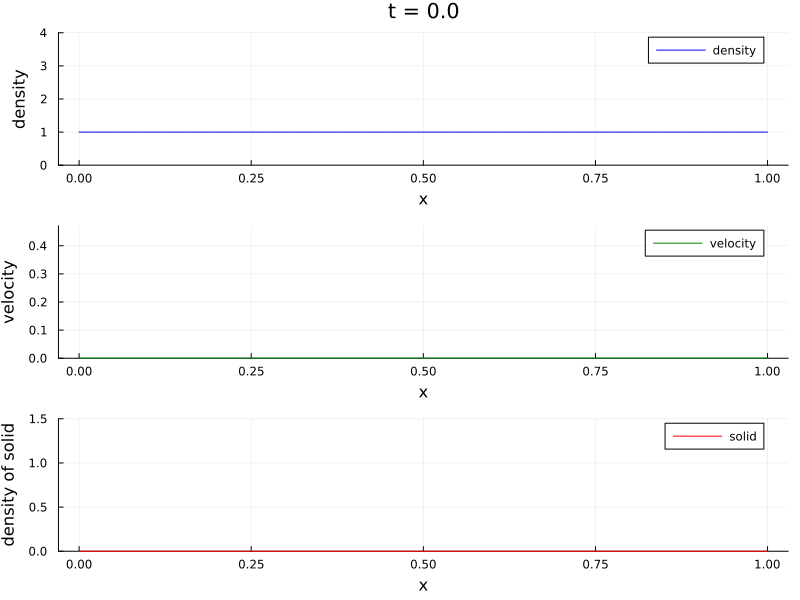

In [ ]:
# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 1:length(discrete_t)

    # top plot: density + total pressure
    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label = "density",
        color = :blue,
        xlabel = "x",
        ylabel = "density",
        title = "t = $(round(discrete_t[k], digits=3))",
        ylims = (0, 4),
        legend = :topright
    )

    # plot!(
    #     p1,
    #     discrete_x,
    #     sol_ρ_s[:, k],

    #     label = "solid density",
    #     color = :red
    # )

    # bottom plot: velocity
    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label = "velocity",
        color = :green,
        xlabel = "x",
        ylabel = "velocity",
        ylims = (vmin, vmax),
        legend = :topright
    )

    # solid density
    p3 = plot(
        discrete_x,
        sol_ρ_s[:, k],
        label = "solid",
        color = :red,
        xlabel = "x",
        ylabel = "density of solid",
        ylims = (0, 1.5),
        legend = :topright)

    # combine
    plot(
        p1,
        p2,
        p3,
        layout = (3,1),
        size = (800,600)
    )

end

gif(anim, joinpath(folder, "first_result.gif"), fps = 10)

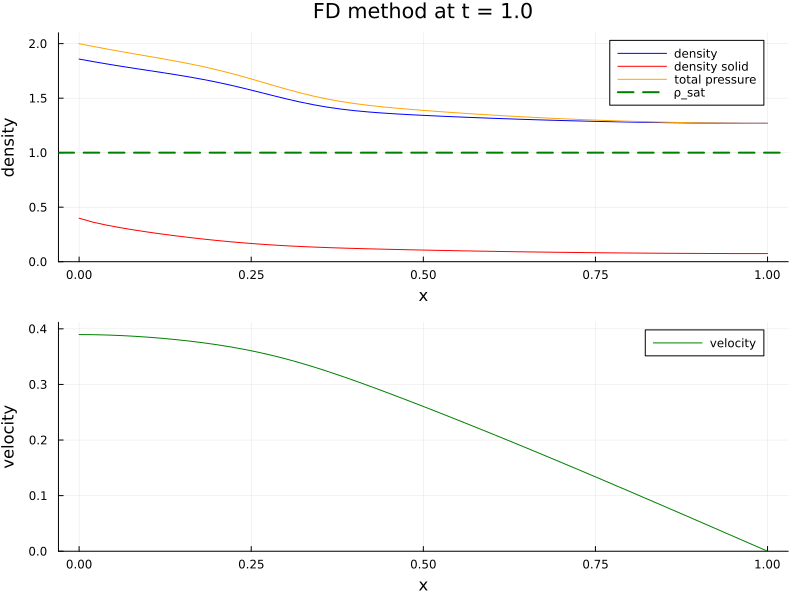

In [ ]:
# limits
k = 10
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

p_tot = R*T*sol_ρ[:, k] + 0.5*sol_ρ[:, k].*sol_v[:, k].^2

p1 = plot(
    discrete_x,
    sol_ρ[:, k],
    label="density",
    color=:blue,
    xlabel="x",
    ylabel="density",
    title="FD method at t = $(round(discrete_t[k+1], digits=3))",
    ylims=(0, 2.1),
    legend=:topright
)

plot!(
    p1,
    discrete_x,
    sol_ρ_s[:, k],
    label="density solid",
    color=:red,
)

plot!(
    p1,
    discrete_x,
    p_tot,
    label="total pressure",
    color=:orange,
)

hline!(p1, 
    [1],
    label = "ρ_sat",
    lw = 2,
    color = :green,
    linestyle = :dash)

p2 = plot(
    discrete_x,
    sol_v[:, k],
    label="velocity",
    color=:green,
    xlabel="x",
    ylabel="velocity",
    ylims=(vmin, vmax),
    legend=:topright
)

plot(p1, p2, layout=(2,1), size=(800,600))


In [18]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_4_FD_ptot.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_4_FD_ptot.png"

In [ ]:
# limits
ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

vmin = minimum(sol_v)
vmax = maximum(sol_v)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 1:length(discrete_t)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=3))",
        ylims=(0, ρmax),
        legend=:topright
    )

    plot!(
        p1,
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
    )

    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

gif(anim, joinpath(folder, "new_plot.gif"), fps=10)

LoadError: UndefVarError: `sol_ρ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
sol.alg

[out#0/image2 @ 000001c5dbaed680] Output file does not contain any stream
Error opening output file C:\Users\noudh\AppData\Local\Temp\jl_8Nj1Pe/palette.bmp.
Error opening output files: Invalid argument


LoadError: failed process: Process(setenv(`[4m'C:\Users\noudh\.julia\artifacts\f693ff97b87421cdea0d854d89b333ccca059472\bin\ffmpeg.exe'[24m [4m-v[24m [4m16[24m [4m-i[24m [4m'C:\Users\noudh\AppData\Local\Temp\jl_8Nj1Pe/%06d.png'[24m [4m-vf[24m [4mpalettegen=stats_mode=full[24m [4m-y[24m [4m'C:\Users\noudh\AppData\Local\Temp\jl_8Nj1Pe/palette.bmp'[24m`,["WINDIR=C:\\WINDOWS", "PATH=C:\\Users\\noudh\\.julia\\artifacts\\3af036b12a076c2d4c042dde6d956ef4eac2c2ce\\bin;C:\\Users\\noudh\\.julia\\juliaup\\julia-1.12.5+0.x64.w64.mingw32\\bin;C:\\Users\\noudh\\.julia\\artifacts\\3e8595790b40695d61440b7b6606c9492bde5d4d\\bin;C:\\Users\\noudh\\.julia\\artifacts\\ce4261864aeaa78b205a3f6fb750be4c4afe9b4b\\bin;C:\\Users\\noudh\\.julia\\artifacts\\1da3b3a2698813adf2b925c46aa2d68ec8474449\\bin;C:\\Users\\noudh\\.julia\\artifacts\\58a307887a7b823f6a7cac7e6337710ec14aced2\\bin;C:\\Users\\noudh\\.julia\\artifacts\\df4cc9189a878ad66ad99fed70ece5cf4e45b246\\bin;C:\\Users\\noudh\\.julia\\artif

# Debugging

In [ ]:
# debugging
sol.retcode
length(sol.t)
sol.t[end]
minimum(sol_ρ)

1.0

In [ ]:
# debugging
sol.stats

SciMLBase.DEStats
Number of function 1 evaluations:                  74283
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    0
Number of linear solves:                           0
Number of Jacobians created:                       0
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          12379
Number of rejected steps:                          1